# Analysis — N Particles

In [13]:
import matplotlib.pyplot as plt
import numpy as np
np.seterr('warn')

from aux_functions import shorten_points
from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, get_xf_yf_fund, get_mean_amp_and_phase

## Configuração
Edite apenas esta célula para adicionar/remover partículas ou frequências.

In [14]:
filenames_all = fetch_data_filenames("./12-05-26_13-05-26")

In [15]:
exc_data_npy = [
    extract_data_info_from_path(data_path_npy) for data_path_npy in filenames_all 
    if ("step" in data_path_npy) and (".npy" in data_path_npy) and ("exc_laser" in data_path_npy)
    ]

In [16]:
#Populate particle list
num_particles = 10
p_list = [
    {
        "p_label": p_id+1,
        "p_data": [
            extract_data_info_from_path(p_data_path)
            for p_data_path in filenames_all
            if (f"p{p_id+1}_lum" in p_data_path) and ("step" in p_data_path) and (".npy" in p_data_path)
        ]
    }
    for p_id in range(num_particles)
]

In [17]:
freq_list = sorted(set([dic["freq"] for dic in exc_data_npy]))

# Layout dos subplots de verificação visual
cols = 4
rows = int(np.ceil(len(freq_list) / cols))
    

## Análise — loop sobre N partículas

In [18]:
def time_domain_visual_verification(particles: list):

    for p_idx, p_dic in enumerate(particles):
        particle_label = f"Particle {p_dic['p_label']}"
        # correct = adj_phase_correction[p_idx] if p_idx < len(adj_phase_correction) else False

        print(f"\n{'='*50}")
        print(f"  Processing particle {p_dic['p_label']}  ")
        print(f"{'='*50}")

        omegas      = []
        phase_diffs = []

        # ---- Subplots de verificação visual ----
        fig, axs = plt.subplots(rows, cols, figsize=(12, 12), constrained_layout=True)
        fig.suptitle(f"Particle {p_dic["p_label"]}", fontsize=14)

        # data = p_dic["p_data"]

        for index, step_data in enumerate(p_dic["p_data"]):
            freq = step_data["freq"]
            i, j = divmod(index, cols)
            omega = 2 * np.pi * float(freq) * 1e-6
            omegas.append(omega)

            # Colocar para fazer calcular fases média

            ax = axs[i, j]
            for idx_rep, rep in enumerate(step_data["data"]):
                ax.plot(rep[:,0], rep[:,1])

            ax.set_title(f"{freq} Hz")


        plt.show()

# time_domain_visual_verification(p_list)

## Get mean phases and errors

In [19]:
#Calculate list of phasors for the laser and all measurements
for step in exc_data_npy:
  freq = step["freq"]
  step["fft_amp_list"] = []
  for meas_idx, meas in enumerate(step["data"]):
    _, amp = get_xf_yf_fund(meas[:,0], meas[:,1])
    step["fft_amp_list"].append(amp)

In [20]:
# Get mean phase and error for each particle and each step (freq) 
for step in exc_data_npy:
    freq = step["freq"]
    amp_list = step["fft_amp_list"]
    _, _, phase, phase_error = get_mean_amp_and_phase(amp_list)
    step["mean_fft_info"] = [freq, phase, phase_error]

In [21]:
#Calculate list of phasors for all particles and all measurements
for p in p_list:
  for step in p["p_data"]:
    freq = step["freq"]
    step["fft_amp_list"] = []
    for meas_idx, meas in enumerate(step["data"]):
      _, amp = get_xf_yf_fund(meas[:,0], meas[:,1])
      step["fft_amp_list"].append(amp)

In [22]:
# Get mean phase and error for each particle and each step (freq) 
for p in p_list:
    for step in p["p_data"]:
        freq = step["freq"]
        amp_list = step["fft_amp_list"]
        _, _, phase, phase_error = get_mean_amp_and_phase(amp_list)
        step["mean_fft_info"] = [freq, phase, phase_error]

## Comparison — all particles

In [23]:
def get_error_bar(exc_data, p_list):
    exc_mean_phase = np.array([
            step["mean_fft_info"]
            #[freq, phase, phase_error]
            for step in exc_data
        ])
    error_exc = exc_mean_phase[:,2]
    # print(error_exc)

    for p in p_list:
        # if p["p_label"] !=1: continue
        p_mean_phase = np.array([
            step["mean_fft_info"]
            for step in p["p_data"]
            ])
        
        if (p_mean_phase[:,0]-exc_mean_phase[:,0]).sum() != 0.:
            print("Deu ruim!")
            return None
        else:
            pd_list = np.unwrap(p_mean_phase[:,1]-exc_mean_phase[:,1])
            pd_error = np.hypot(
                p_mean_phase[:,2],
                exc_mean_phase[:,2]
            )

        p["error_bar"] = np.column_stack((p_mean_phase[:,0], pd_list, pd_error))

get_error_bar(exc_data_npy, p_list)

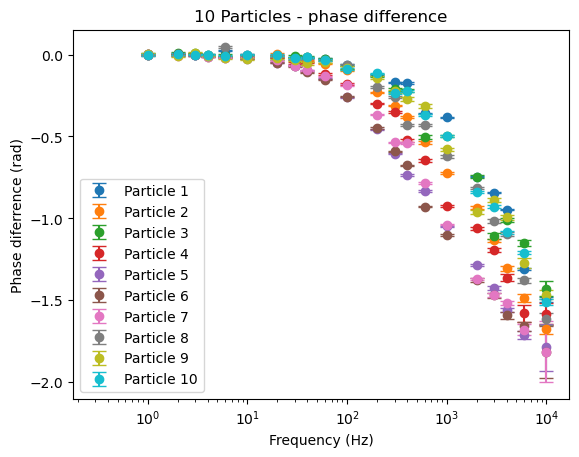

In [24]:
def plot_phase_difference(particles: list, p_to_skip = [], freqs_to_skip = []):
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for p_id, p in enumerate(particles):
        if p["p_label"] in p_to_skip: continue
        color = colors[p_id % len(colors)]
        # p["error_bar"]
        label_added = False
        for idx, error_point in enumerate(p["error_bar"]):
            # Skip frequencies larger than 20kHz
            if (error_point[0] in freqs_to_skip): 
                # print(f"Não foi calculado pra freq: {error_point[0]}Hz")
                continue
            
            current_label = f"Particle {p['p_label']}" if not label_added else None

            plt.errorbar(
                error_point[0],
                error_point[1],
                yerr=error_point[2],
                label=current_label,
                fmt='o',
                capsize=5,
                color=color,
            )
            label_added = True
        # plt.title(f"Particle {p['p_label']}  - phase difference")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Phase diferrence (rad)")
        plt.xscale("log")
    plt.title(f"{len(particles)} Particles - phase difference")
    plt.legend()
    plt.show()

plot_phase_difference(p_list, p_to_skip=[], freqs_to_skip=[20000, 40000])